---
title: 向量加法实验 · CPU 实测
---

# 向量加法：把预测变成证据

这是骨架中的 CPU 实验示例。初始输出由搭建时的环境真实生成，不代表你的远程机器。先写下自己的预测，再在远程环境重新运行。

目标：观察输入规模、调用开销与缓存如何影响耗时和有效带宽。没有预设哪个输入一定更快，也不把此实验当作 GPU 或 DRAM 峰值测量。

## 1. 运行前预测

- 很小的数组与很大的数组，谁的有效带宽可能更高？依据是什么？
- 预分配 `out` 去掉了什么成本？还有哪些成本没有去掉？
- 如果得到的有效 GB/s 很大，是否一定说明 DRAM 带宽很大？

在这里填写自己的解释；当前模板尚未记录你的回答。

## 2. 环境与运行位置

在服务器按本主题 `requirements.txt` 安装环境，选择对应 kernel。工作目录应为 `lab.ipynb` 所在目录；仓库的 VS Code 设置已指定 `${fileDirname}`。CLI 会记录当前环境、实际代码版本和原始计时。首次搭建尚未提交时，版本为 `null`，并记录工作区修改状态。

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

TOPIC = Path.cwd().resolve()
REPO = TOPIC.parents[2]
plt.style.use(REPO / "assets/styles/plots.mplstyle")
tokens = json.loads((REPO / "assets/styles/tokens.json").read_text())
colors = tokens["colors"]
RUN_CONTEXT = "CPU learning example; inspect the recorded machine before comparisons."
RUN_DIR = TOPIC / "results/example-cpu"
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Topic:", TOPIC)


Python: 3.13.2
NumPy: 2.3.2
Topic: /home/lixinyuan/ai-infra-learning/topics/foundations/performance-model


## 3. 运行最小实验

四个数组长度分别为 1,024、16,384、262,144、4,194,304。每个规模预热 3 次、计时 25 次；输入和输出均为 float32，使用预分配输出的 `np.add(x, y, out=out)`。

改运行条件时也更新 `RUN_CONTEXT`。这一步会更新本次选定的 `results/example-cpu`；新的独立运行可更换 `RUN_DIR`。

In [2]:
subprocess.run(
    [
        sys.executable, str(TOPIC / "benchmark.py"),
        "--output", str(RUN_DIR),
        "--context", RUN_CONTEXT,
    ],
    check=True,
)
record = json.loads((RUN_DIR / "run.json").read_text())
print(json.dumps(record["environment"], indent=2))
print("Recorded at:", record["recorded_at_utc"])


Recorded CPU run: /home/lixinyuan/ai-infra-learning/topics/foundations/performance-model/results/example-cpu
    1,024 elements:       0.41 us,    30.19 effective GB/s
   16,384 elements:       1.58 us,   124.12 effective GB/s
  262,144 elements:      28.63 us,   109.86 effective GB/s
4,194,304 elements:    1289.08 us,    39.04 effective GB/s
{
  "platform": "Linux-5.15.167.4-microsoft-standard-WSL2-x86_64-with-glibc2.35",
  "architecture": "x86_64",
  "processor": "x86_64",
  "python": "3.13.2",
  "numpy": "2.3.2",
  "code_revision": null,
  "worktree_dirty": true
}
Recorded at: 2026-10-02T07:58:07.271792+00:00


## 4. 实测曲线与测量范围

用读两个输入、写一个输出估算 `useful_bytes = 12 × elements`。`useful_bytes / elapsed_ns` 在数值上就是十进制 GB/s。

点表示中位计时对应的有效带宽，误差棒表示计时第 25–75 百分位对应的带宽区间；它不是置信区间。图中的赭黄表示访存相关量，参照根目录 STYLE.md。

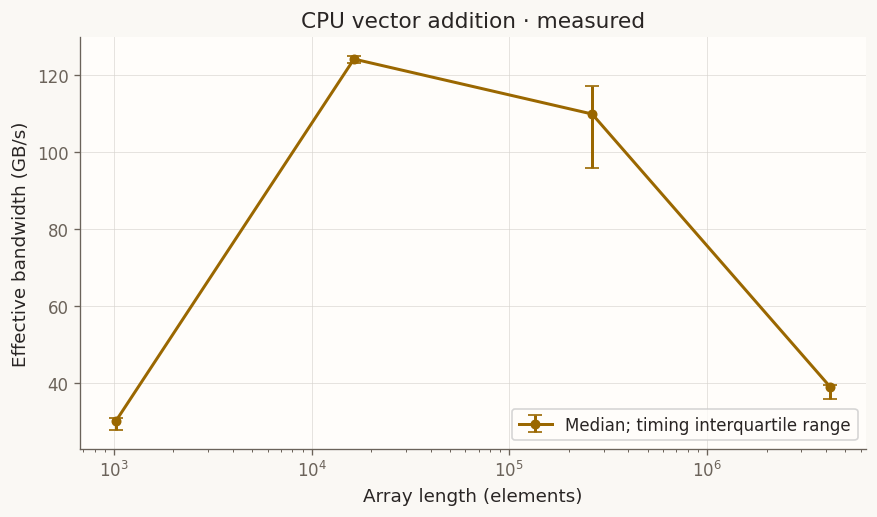

In [3]:
rows = record["results"]
sizes = np.array([row["elements"] for row in rows])
useful_bytes = np.array([row["useful_bytes"] for row in rows])
bandwidth = np.array([row["effective_gb_s"] for row in rows])
lower = useful_bytes / np.array([row["p75_ns"] for row in rows])
upper = useful_bytes / np.array([row["p25_ns"] for row in rows])

fig, ax = plt.subplots()
ax.errorbar(
    sizes, bandwidth,
    yerr=np.vstack([bandwidth - lower, upper - bandwidth]),
    color=colors["memory"], marker="o", capsize=4,
    label="Median; timing interquartile range",
)
ax.set_xscale("log")
ax.set_xlabel("Array length (elements)")
ax.set_ylabel("Effective bandwidth (GB/s)")
ax.set_title("CPU vector addition · measured")
ax.legend()
fig.savefig(TOPIC / "assets/vector-add-effective-bandwidth.svg")
fig.savefig(TOPIC / "assets/vector-add-effective-bandwidth.png")
plt.show()


## 5. 解释结果，而不是替结果编故事

原始样本、命令和环境在 `results/example-cpu/run.json`，汇总在 `summary.csv`。图由这些实际样本生成。

此结果只能描述记录环境中的 NumPy CPU 操作。数据可能来自缓存而不是 DRAM；写分配可能增加实际流量；计时包含调用开销；共享机器的负载与频率也可能影响运行。

重新运行后填写：

- **观察：** 哪些量变化了？波动范围如何？
- **解释：** 当前模型能解释哪部分？需要哪些额外证据？
- **修正：** 原先预测哪里不足？
- **下一步：** 只改变一个条件，你会测什么？

当前没有填写学习者的结论。不能从这张图推断你已经掌握 Roofline，也不能将最高有效带宽当作硬件峰值。

回到 [性能模型](README.md) 对照交互图的假设；剩余问题放入 [GAPS](../../../GAPS.md)。